In [4]:
from Bio import motifs
from Bio import SeqIO
from Bio.Seq import Seq

import numpy as np
import matplotlib.pyplot as plt

# опять делаем pwm для нашего мотива
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC",
         "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC", "CAGGTTGGC"]

sites = [Seq(s) for s in sites]
motif = motifs.create(sites)

pwm = motif.counts.normalize(pseudocounts=0.1).log_odds()
print(motif.consensus)

# рандомный генератор последовательностей
def generator(num: int, length: int):
    seqs = [np.random.random_integers(low=0, high=3, size=(num, length))]
    mapping = np.array(['A', 'T', 'G', 'C'])
    seqs = mapping[seqs]
    return seqs

seqs = generator(100000, 9)[0]


# считаем скоры по нашему pwm
scores = []
for k in range(100000):
    score = 0
    for i in range(9):
        score += pwm[seqs[k][i]][i]
    scores.append(score)

scores = np.array(scores)

CAGGTCAGC


/var/folders/pp/2nmc3bb534nbjhvc041mrt5c0000gn/T/ipykernel_40128/2978227046.py:20: DeprecationWarning: This function is deprecated. Please call randint(0, 3 + 1) instead
  seqs = [np.random.random_integers(low=0, high=3, size=(num, length))]


(array([8.45632443e-04, 7.11100009e-04, 0.00000000e+00, 0.00000000e+00,
        4.61254060e-04, 0.00000000e+00, 4.32425681e-03, 0.00000000e+00,
        4.88160547e-03, 7.49537847e-04, 1.55673245e-03, 4.03597302e-03,
        4.24738113e-03, 7.78366226e-03, 7.87975686e-04, 1.51637272e-02,
        1.26844866e-02, 3.07502707e-03, 1.85846948e-02, 1.28382380e-02,
        1.75084354e-02, 1.97762678e-02, 1.04935299e-02, 2.71178949e-02,
        2.20633192e-02, 2.14867516e-02, 3.06349571e-02, 3.92450329e-02,
        2.11792489e-02, 3.59393788e-02, 4.08978600e-02, 3.55742194e-02,
        4.48953952e-02, 5.36784412e-02, 3.95717546e-02, 4.62791573e-02,
        4.86430844e-02, 4.25891249e-02, 4.66250979e-02, 5.55618953e-02,
        5.31018736e-02, 5.87714548e-02, 4.66827546e-02, 4.68365060e-02,
        6.54596387e-02, 4.87007412e-02, 3.90912816e-02, 5.73492548e-02,
        5.55618953e-02, 4.34347573e-02, 3.86492464e-02, 4.97001250e-02,
        3.76883005e-02, 3.83225248e-02, 4.07825465e-02, 3.130761

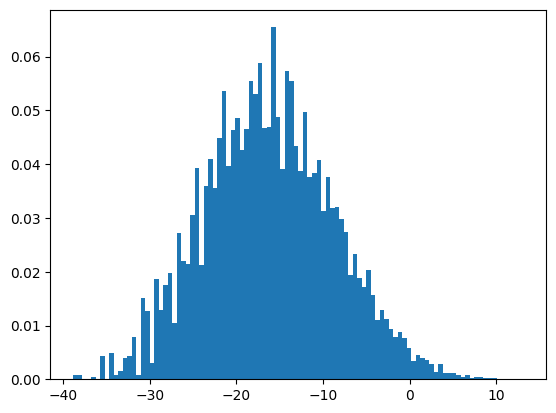

In [9]:
plt.hist(scores, bins=100, density=True)

In [11]:
def get_pvalue(score, background_scores):
    ''' шедевро пи валью'''
    return np.mean(background_scores >= score)

target_p = 1e-4

threshold = np.quantile(scores, 1 - target_p)

print("Threshold for p ≈ 1e-4:", threshold)
print("Actual p-value:", get_pvalue(threshold, scores))



Threshold for p ≈ 1e-4: 10.89716910042492
Actual p-value: 0.0001
